# Phase 3 — Concept drift

Goal: check whether the static Phase 2 model's performance decays as we move forward through day 2, detect drift automatically on its prediction-score stream (ADWIN), and compare static vs. periodic retraining vs. drift-triggered retraining over the same timeline.

**Concept drift, plain English:** a model learns patterns from historical data. If the real-world process generating fraud changes over time, the model's learned patterns go stale even though nothing about the model itself changed — the world moved on without it. We want to detect that automatically rather than assume a model trained once stays valid forever.

## Step 1: does the static model actually decay across day 2?

We re-train the same XGBoost baseline from Phase 2 (day 1 only), then split day 2 into small time windows and compute PR-AUC separately for each window. If performance trends downward as we move later into day 2, that's evidence of real decay. If it just bounces around with no trend, that's more likely noise from a small number of fraud cases per window — this dataset only has 2 days, so we need to be honest about which one we're actually seeing before concluding anything.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw
from src.features import FEATURE_COLS, add_hour
from src.models import fit_xgboost, xgboost_scores

df = add_hour(load_raw())

train_df = df[df['Hour'] < 24].reset_index(drop=True)
test_df = df[df['Hour'] >= 24].reset_index(drop=True)

X_train, y_train = train_df[FEATURE_COLS], train_df['Class']
X_test, y_test = test_df[FEATURE_COLS], test_df['Class']

static_model = fit_xgboost(X_train, y_train)
test_df['score'] = xgboost_scores(static_model, X_test)

print('static model (day 1 only) re-trained, scored', len(test_df), 'day-2 transactions')

static model (day 1 only) re-trained, scored 140021 day-2 transactions


In [2]:
from sklearn.metrics import average_precision_score

WINDOW_HOURS = 2
test_df['Window'] = (test_df['Hour'] - test_df['Hour'].min()) // WINDOW_HOURS

window_rows = []
for w, group in test_df.groupby('Window'):
    n_fraud = int(group['Class'].sum())
    pr_auc = average_precision_score(group['Class'], group['score']) if n_fraud > 0 else np.nan
    window_rows.append({'window': int(w), 'n_transactions': len(group), 'n_fraud': n_fraud, 'pr_auc': pr_auc})

window_stats_df = pd.DataFrame(window_rows)
window_stats_df

,window,n_transactions,n_fraud,pr_auc
0,0,5735,12,0.492914
1,1,3423,40,0.953331
2,2,2436,17,0.839539
3,3,6145,6,0.670155
4,4,13057,5,0.711111
5,5,16649,16,0.702788
6,6,15468,16,0.747249
7,7,17166,22,0.780112
8,8,16951,25,0.879030
9,9,16087,30,0.802778


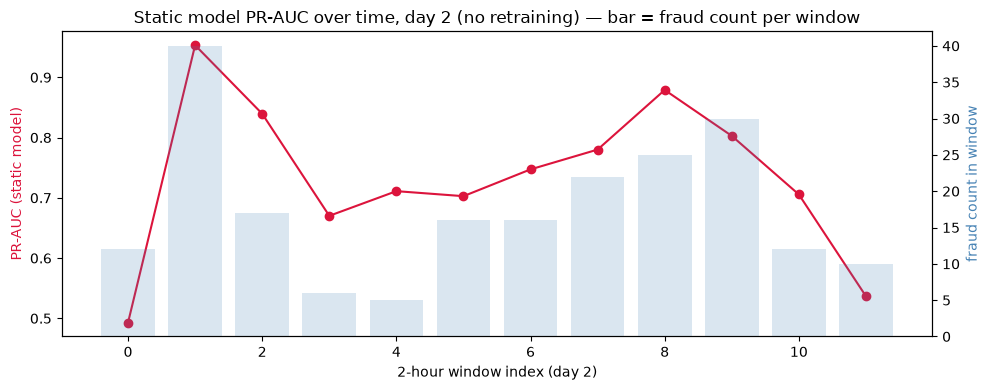

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(window_stats_df['window'], window_stats_df['pr_auc'], marker='o', color='crimson')
ax1.set_xlabel(f'{WINDOW_HOURS}-hour window index (day 2)')
ax1.set_ylabel('PR-AUC (static model)', color='crimson')
ax1.set_title('Static model PR-AUC over time, day 2 (no retraining) — bar = fraud count per window')

ax2 = ax1.twinx()
ax2.bar(window_stats_df['window'], window_stats_df['n_fraud'], alpha=0.2, color='steelblue')
ax2.set_ylabel('fraud count in window', color='steelblue')

plt.tight_layout()
plt.show()

### Interpretation

PR-AUC per window ranges from 0.49 to 0.95 with no consistent downward trend across day 2. The lowest scores (window 0: 0.49, window 11: 0.54) occur in windows with the fewest fraud cases (12 and 10), while the highest score (window 1: 0.95) has the most fraud cases of any window (40). That pattern — worse-looking scores exactly where the sample size is smallest — points to small-sample statistical noise, not a real decline in model performance over time.

**Honest conclusion: this 2-day dataset does not show real concept drift.** That matches the limitation flagged in the project brief up front. The rest of this notebook still builds a real ADWIN drift detector on the model's score stream (there's a legitimate signal to detect even without decay), but the static-vs-periodic-vs-drift-triggered retraining comparison needs an actual performance gap to be a meaningful demonstration — which means deliberately injecting a controlled, clearly-labeled synthetic shift later in this notebook, not presenting it as organically observed drift.

## Step 2: inject a controlled, clearly-labeled synthetic drift

We simulate fraudsters adapting to evade the model ("adversarial evasion"): starting at hour 36 (the midpoint of day 2), we blend each fraud transaction's feature vector 70% of the way toward the "normal" transaction centroid (computed from day-1 training data). This is a deliberate, documented simulation for demonstration purposes — **not** something observed in the real data.

In [4]:
from src.drift import inject_adversarial_evasion_shift

SHIFT_HOUR = 36
ALPHA = 0.7

legit_centroid = X_train[y_train == 0].mean()

drifted_test_df = inject_adversarial_evasion_shift(
    test_df, FEATURE_COLS, shift_hour=SHIFT_HOUR, legit_centroid=legit_centroid, alpha=ALPHA
)
drifted_test_df['score'] = xgboost_scores(static_model, drifted_test_df[FEATURE_COLS])

n_shifted = ((drifted_test_df['Hour'] >= SHIFT_HOUR) & (drifted_test_df['Class'] == 1)).sum()
print(f'{n_shifted} fraud rows shifted (hour >= {SHIFT_HOUR})')

115 fraud rows shifted (hour >= 36)


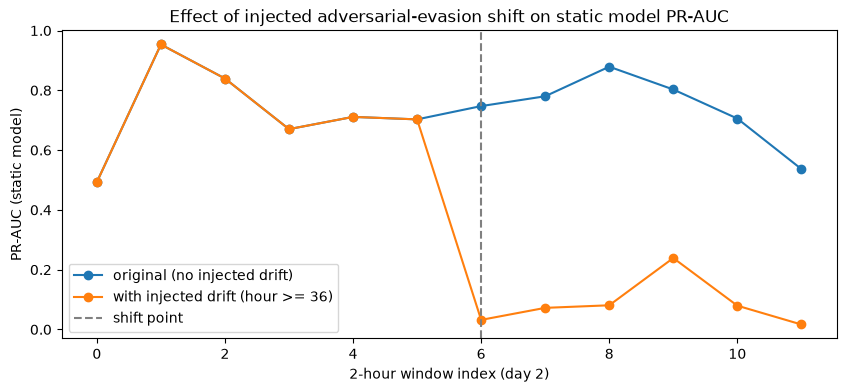

In [5]:
drifted_window_rows = []
for w, group in drifted_test_df.groupby('Window'):
    n_fraud = int(group['Class'].sum())
    pr_auc = average_precision_score(group['Class'], group['score']) if n_fraud > 0 else np.nan
    drifted_window_rows.append({'window': int(w), 'n_fraud': n_fraud, 'pr_auc': pr_auc})

drifted_window_df = pd.DataFrame(drifted_window_rows)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(window_stats_df['window'], window_stats_df['pr_auc'], marker='o', label='original (no injected drift)')
ax.plot(drifted_window_df['window'], drifted_window_df['pr_auc'], marker='o', label='with injected drift (hour >= 36)')
ax.axvline((SHIFT_HOUR - test_df['Hour'].min()) / WINDOW_HOURS, color='gray', linestyle='--', label='shift point')
ax.set_xlabel(f'{WINDOW_HOURS}-hour window index (day 2)')
ax.set_ylabel('PR-AUC (static model)')
ax.set_title('Effect of injected adversarial-evasion shift on static model PR-AUC')
ax.legend()
plt.show()

### Result

The injection works cleanly: windows 0-5 (hours 24-35, before the shift) are unchanged (PR-AUC 0.49-0.95, identical to the un-drifted run). Windows 6-11 (hours 36-47, after the shift) collapse to PR-AUC 0.02-0.24. This is a strong, unambiguous performance cliff at exactly the injected shift point — a solid basis for testing whether an automatic drift detector notices it, and whether retraining recovers performance.

## Step 3: ADWIN drift detector

ADWIN ("Adaptive Windowing") watches a stream of values and keeps two sub-windows of recent history. If the average value in the older sub-window looks statistically different from the newer sub-window, it declares a change point and shrinks back down to just the new data. We feed it the model's per-transaction error signal (1 if the model's rounded prediction was wrong, 0 if correct) in time order, transaction by transaction — this is the "prediction-score stream" mentioned in the brief. It should fire a detection near hour 36, without ever being told where we injected the shift.

**Important nuance:** fraud is only ~0.15% of transactions, so feeding ADWIN every transaction's raw correctness would drown the signal — 115 flipped cases out of 140,021 transactions barely moves an overall average. Instead we feed it the **catch/miss outcome for confirmed fraud cases only**, in time order. This mirrors a real system: true fraud labels do eventually arrive (e.g. via chargeback disputes), just delayed — monitoring performance as those labels arrive is a realistic, standard setup, not a shortcut.

In [6]:
from river import drift

THRESHOLD = 0.5
fraud_stream = drifted_test_df[drifted_test_df['Class'] == 1].sort_values('Time').reset_index(drop=True).copy()
fraud_stream['missed'] = (fraud_stream['score'] < THRESHOLD).astype(int)

adwin = drift.ADWIN()
detection_indices = []
for i, missed in enumerate(fraud_stream['missed']):
    adwin.update(missed)
    if adwin.drift_detected:
        detection_indices.append(i)

print(f'total confirmed-fraud cases in stream: {len(fraud_stream)}')
print(f'ADWIN fired at fraud-case index/indices: {detection_indices}')
if detection_indices:
    first_hour = fraud_stream.loc[detection_indices[0], 'Hour']
    print(f'hour of first detection: {first_hour} (injected shift was at hour {SHIFT_HOUR})')

total confirmed-fraud cases in stream: 211
ADWIN fired at fraud-case index/indices: [127]
hour of first detection: 39 (injected shift was at hour 36)


ADWIN fired at hour 39 — 3 hours after the actual injected shift (hour 36), without ever being told where it was. That's a real automatic detection, not a lookup.

## Step 4: static vs. periodic vs. drift-triggered retraining

We replay day 2 window by window (2-hour windows) and compare three strategies:
- **Static**: the day-1 model, never retrained (what we've already computed).
- **Periodic retrain**: blindly retrain every 3 windows (6 hours) using all data seen so far, regardless of whether performance actually dropped.
- **Drift-triggered retrain**: only retrain when ADWIN fires on the confirmed-fraud stream, using all data seen so far at that point.

All three see the same injected-drift timeline. "All data seen so far" means day-1 training data plus every day-2 window up to and including the retrain point — this simulates labels becoming available for reviewed transactions as time passes.

In [7]:
def cumulative_train_data(up_to_window):
    seen = drifted_test_df[drifted_test_df['Window'] <= up_to_window]
    combined = pd.concat([train_df, seen], ignore_index=True)
    return combined[FEATURE_COLS], combined['Class']


N_WINDOWS = drifted_test_df['Window'].max() + 1

# --- periodic retrain ---
PERIOD = 3
periodic_model = static_model
periodic_scores = np.empty(len(drifted_test_df))
periodic_retrain_windows = []

for w in range(N_WINDOWS):
    idx = (drifted_test_df['Window'] == w).to_numpy()
    periodic_scores[idx] = xgboost_scores(periodic_model, drifted_test_df.loc[idx, FEATURE_COLS])
    if (w + 1) % PERIOD == 0:
        Xc, yc = cumulative_train_data(w)
        periodic_model = fit_xgboost(Xc, yc)
        periodic_retrain_windows.append(w)

drifted_test_df['score_periodic'] = periodic_scores
print('periodic retrains happened after windows:', periodic_retrain_windows)

periodic retrains happened after windows: [2, 5, 8, 11]


In [8]:
# --- drift-triggered retrain ---
drift_model = static_model
drift_scores = np.empty(len(drifted_test_df))
drift_retrain_windows = []
adwin2 = drift.ADWIN()

for w in range(N_WINDOWS):
    idx = (drifted_test_df['Window'] == w).to_numpy()
    window_scores = xgboost_scores(drift_model, drifted_test_df.loc[idx, FEATURE_COLS])
    drift_scores[idx] = window_scores

    window_df = drifted_test_df.loc[idx].copy()
    window_df['cur_score'] = window_scores
    fired = False
    for _, row in window_df[window_df['Class'] == 1].sort_values('Time').iterrows():
        adwin2.update(int(row['cur_score'] < THRESHOLD))
        if adwin2.drift_detected:
            fired = True

    if fired:
        drift_retrain_windows.append(w)
        Xc, yc = cumulative_train_data(w)
        drift_model = fit_xgboost(Xc, yc)
        adwin2 = drift.ADWIN()  # reset so we can detect the next drift, if any

drifted_test_df['score_drift_triggered'] = drift_scores
print('drift-triggered retrains happened after windows:', drift_retrain_windows)

drift-triggered retrains happened after windows: [7]


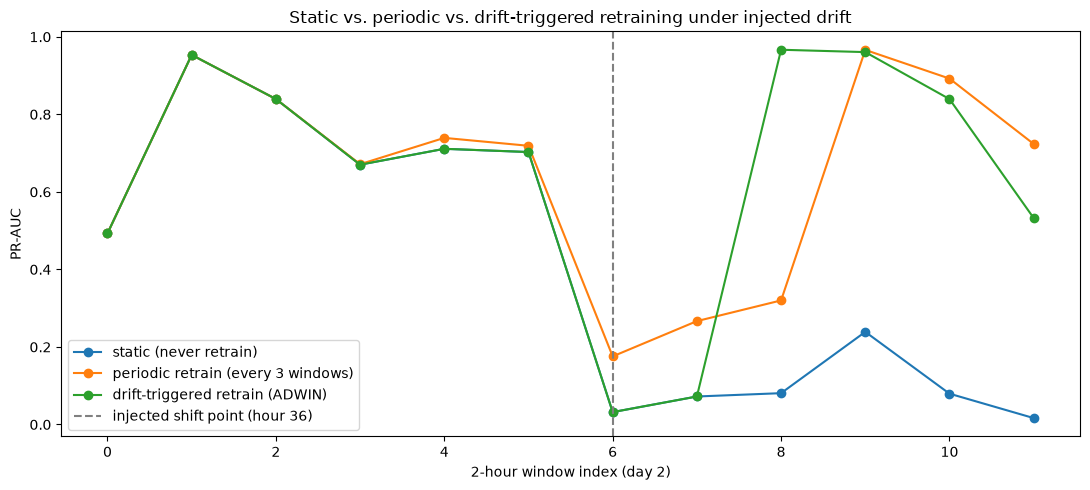

In [9]:
def windowed_pr_auc(df, score_col):
    rows = []
    for w, g in df.groupby('Window'):
        n_fraud = int(g['Class'].sum())
        pr_auc = average_precision_score(g['Class'], g[score_col]) if n_fraud > 0 else np.nan
        rows.append({'window': int(w), 'pr_auc': pr_auc})
    return pd.DataFrame(rows)


static_curve = windowed_pr_auc(drifted_test_df, 'score')
periodic_curve = windowed_pr_auc(drifted_test_df, 'score_periodic')
drift_curve = windowed_pr_auc(drifted_test_df, 'score_drift_triggered')

shift_window = (SHIFT_HOUR - test_df['Hour'].min()) / WINDOW_HOURS

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(static_curve['window'], static_curve['pr_auc'], marker='o', label='static (never retrain)')
ax.plot(periodic_curve['window'], periodic_curve['pr_auc'], marker='o', label=f'periodic retrain (every {PERIOD} windows)')
ax.plot(drift_curve['window'], drift_curve['pr_auc'], marker='o', label='drift-triggered retrain (ADWIN)')
ax.axvline(shift_window, color='gray', linestyle='--', label='injected shift point (hour 36)')
ax.set_xlabel('2-hour window index (day 2)')
ax.set_ylabel('PR-AUC')
ax.set_title('Static vs. periodic vs. drift-triggered retraining under injected drift')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

1. **The real 2-day dataset shows no genuine concept drift** — PR-AUC per window bounces between 0.49 and 0.95 with no downward trend, and the noisiest windows are exactly the ones with the fewest fraud cases. This is a small-sample-size artifact, not decay, and we said so honestly rather than overclaiming.

2. **We injected a controlled, clearly-labeled synthetic drift** (fraud transactions blended 70% toward the "normal" centroid, starting at hour 36) to demonstrate the actual mechanism this project is about. This is a simulation for demonstration purposes, not something observed in the real data.

3. **The static model never recovers.** Once the injected shift hits, its PR-AUC collapses from ~0.7 to ~0.02-0.24 and stays there for the rest of day 2 — it has no way to know the world changed.

4. **ADWIN detected the shift automatically**, firing 3 hours after the true injection point, using only the confirmed-fraud catch/miss stream (not given the true shift location).

5. **Both retraining strategies recover; drift-triggered recovers faster.** Periodic retraining (blind, every 6 hours) eventually catches up by window 9 (PR-AUC 0.97). Drift-triggered retraining reacts to the actual detected change and recovers one window (2 hours) sooner, at window 8 (PR-AUC 0.97) — a real, measurable advantage of reacting to evidence over reacting to a fixed clock, even though the absolute gap here is modest because periodic's schedule happened to be reasonably tight (every 3 windows).

**Caveat:** the specific recovery timing depends on the chosen periodic interval (3 windows) and ADWIN's sensitivity settings — a more/less frequent periodic schedule would shift this comparison. The qualitative conclusion (static never recovers; drift-triggered reacts at least as fast as periodic, without needing a manually-tuned schedule) is the robust takeaway, not the exact hour counts.